# 🚢 Titanic Survival Prediction — Beginner ML Project

This notebook walks through a complete, beginner-friendly machine learning workflow using the classic **Titanic dataset**. The goal is to predict whether a passenger survived, based on features like age, sex, ticket class, and fare.

**Steps covered:**
1. Import libraries
2. Load the dataset
3. Explore the data
4. Clean the data (handle missing values)
5. Visualize the data
6. Encode categorical (text) columns into numbers
7. Prepare features and train/test split
8. Train a Logistic Regression model
9. Evaluate the model's accuracy

Each code cell below has comments explaining exactly what it does and why — so if you're new to ML or pandas, you can follow along step by step.

## 1. Import Libraries
We start by importing all the tools (libraries) we'll need throughout the project.

In [46]:
# Import all the libraries we'll need for this project

# NumPy: for numerical operations and working with arrays
import numpy as np

# Pandas: for loading and manipulating our dataset (tables/DataFrames)
import pandas as pd

# Matplotlib: the base library for creating plots and charts
import matplotlib.pyplot as plt

# Seaborn: built on top of matplotlib, makes nicer-looking statistical charts
import seaborn as sns

# train_test_split: splits our data into a training set and a testing set
from sklearn.model_selection import train_test_split

# LogisticRegression: the machine learning model we'll use for this
# classification problem (predicting Survived = 0 or 1)
from sklearn.linear_model import LogisticRegression

# accuracy_score: metric to check how many predictions our model got right
from sklearn.metrics import accuracy_score

# LabelEncoder: converts text categories (like "male"/"female") into numbers,
# since ML models can only work with numeric data
from sklearn.preprocessing import LabelEncoder

## 2. Load the Dataset
Read the Titanic data from a CSV file into a pandas DataFrame so we can work with it.

In [5]:
# Load the Titanic dataset from a CSV file into a pandas DataFrame
# A DataFrame is basically a table, like an Excel sheet, that we can work with in Python
titanic_dataset = pd.read_csv("tested.csv")

## 3. Explore the Data
Before doing anything else, it's good practice to look at the data: its shape, structure, and whether any values are missing.

In [6]:
# .head() shows the first 5 rows of the dataset
# This gives us a quick look at what columns exist and what kind of values they contain
titanic_dataset.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [8]:
# .shape tells us the size of the dataset: (number_of_rows, number_of_columns)
titanic_dataset.shape

(418, 12)

In [9]:
# .info() gives a summary of the DataFrame:
# - column names
# - number of non-null (non-missing) values in each column
# - data type of each column (int, float, object/text, etc.)
titanic_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [11]:
# Check how many missing (null) values exist in each column
# This is an important step before training any model, since ML models
# generally can't handle missing values on their own
print(titanic_dataset.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


## 4. Clean the Data
Handle missing values so the dataset is complete and ready for analysis/modeling.

In [16]:
# The 'Cabin' column has too many missing values to be useful,
# so we simply drop (remove) it from the dataset
titanic_dataset = titanic_dataset.drop(columns='Cabin')

KeyError: "['Cabin'] not found in axis"

In [17]:
# Display the dataset again to confirm the 'Cabin' column has been removed
titanic_dataset

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,S


In [19]:
# The 'Age' column has some missing values.
# Instead of dropping rows, we fill (impute) the missing ages
# with the average (mean) age of all passengers.
# This is a simple and common way to handle missing numeric data.
titanic_dataset['Age'] = titanic_dataset['Age'].fillna(titanic_dataset['Age'].mean())

In [20]:
# Check the most common value (mode) in the 'Embarked' column
# (the port where passengers boarded the ship).
# We'll use this to fill any missing values in that column.
print(titanic_dataset['Embarked'].mode())

0    S
Name: Embarked, dtype: object


In [25]:
# Similarly, fill any missing 'Fare' values with the average fare.
# This keeps the dataset complete without losing rows of data.
titanic_dataset['Fare'] = titanic_dataset['Fare'].fillna(titanic_dataset['Fare'].mean())

In [27]:
# Check how many passengers survived (1) vs did not survive (0)
# This helps us understand if our dataset is balanced or imbalanced
titanic_dataset['Survived'].value_counts()

Survived
0    266
1    152
Name: count, dtype: int64

## 5. Visualize the Data
Charts help us understand patterns — for example, whether survival was related to gender or passenger class.

In [28]:
# Apply Seaborn's default styling to make our upcoming plots look cleaner
sns.set()

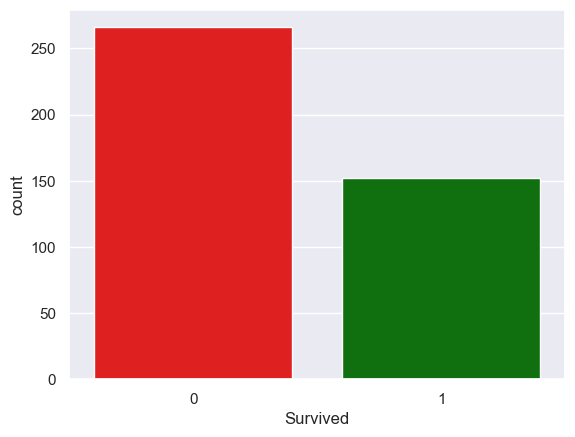

In [35]:
# Bar chart: count of passengers who survived vs did not survive
# Red = did not survive, Green = survived
sns.countplot(
    x='Survived',
    hue='Survived',
    data=titanic_dataset,
    palette=['red', 'green'],
    legend=False
)
plt.show()

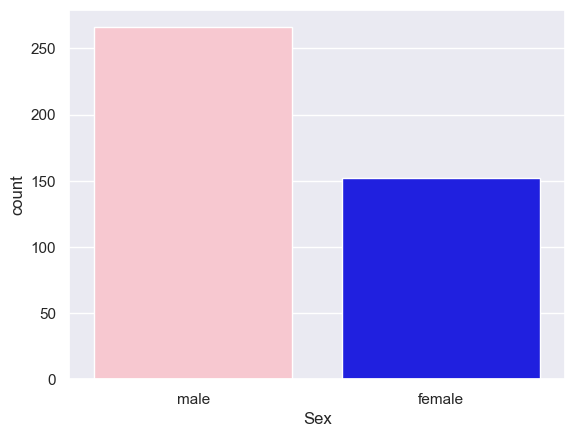

In [37]:
# Bar chart: survival counts broken down by gender (Sex)
# This helps us see if gender had an impact on survival rate
sns.countplot(
    x='Sex',
    hue='Survived',
    data=titanic_dataset,
    palette=['pink', 'blue'],
    legend=False
)
plt.show()

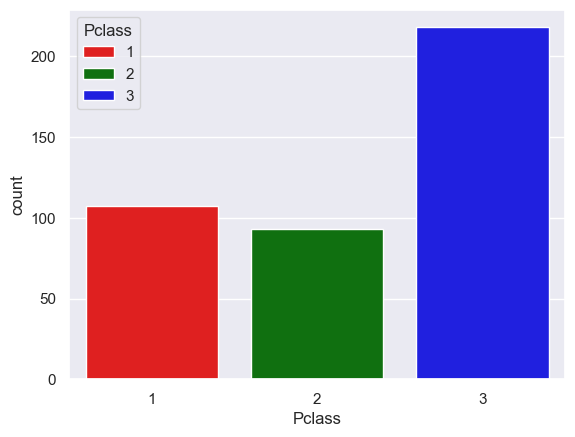

In [43]:
# Bar chart: number of passengers in each passenger class (Pclass)
# Pclass 1 = first class, 2 = second class, 3 = third class
sns.countplot(
    x='Pclass',
    hue='Pclass',
    data=titanic_dataset,
    palette=['red', 'green', 'blue'],
    legend=True
)
plt.show()

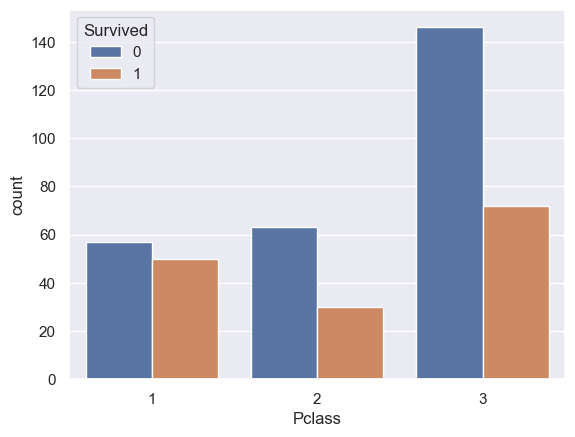

In [44]:
# Bar chart: survival counts broken down by passenger class
# This helps us see if wealthier/higher-class passengers had a better survival rate
sns.countplot(
    x = 'Pclass',
    hue = 'Survived',
    data = titanic_dataset
)
plt.show()
    

## 6. Encode Categorical Columns
ML models need numbers, not text. Here we convert text columns like 'Sex' and 'Embarked' into numeric codes.

In [60]:
# Machine learning models need numeric input, but 'Sex' and 'Embarked'
# currently contain text (e.g. "male"/"female", "S"/"C"/"Q").
# LabelEncoder converts each unique text category into a number (0, 1, 2, ...)
encoder = LabelEncoder()
titanic_dataset['Sex'] = encoder.fit_transform(titanic_dataset['Sex'])
titanic_dataset['Embarked'] = encoder.fit_transform(titanic_dataset['Embarked'])

In [61]:
# Confirm that 'Sex' and 'Embarked' are now numeric types instead of text
print(titanic_dataset.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Name             int64
Sex              int64
Age            float64
SibSp            int64
Parch            int64
Ticket           int64
Fare           float64
Embarked         int64
dtype: object


In [62]:
# Take another look at the dataset to see the encoded columns in action
titanic_dataset.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,0,3,206,1,34.5,0,0,152,7.8292,1
1,893,1,3,403,0,47.0,1,0,221,7.0000,2
2,894,0,2,269,1,62.0,0,0,73,9.6875,1
3,895,0,3,408,1,27.0,0,0,147,8.6625,2
4,896,1,3,178,0,22.0,1,1,138,12.2875,2


## 7. Prepare Features & Split the Data
Separate the dataset into inputs (X) and the target we want to predict (y), then split into training and testing sets.

In [64]:
# Prepare our features (X) and target/label (y) for the model
# X: all columns EXCEPT the ones that don't help prediction
#    (PassengerId is just an ID, Survived is what we're predicting,
#     Ticket and Name are text fields that aren't useful here without extra processing)
# y: the column we want to predict, i.e. whether the passenger survived
X = titanic_dataset.drop(columns = ['PassengerId','Survived','Ticket','Name'] , axis = 1)
y = titanic_dataset['Survived']

In [68]:
# Split the data into training data (used to teach the model)
# and testing data (used to check how well the model performs on unseen data)
# test_size = 0.2 means 20% of the data is reserved for testing, 80% for training
# random_state = 42 makes the split reproducible (same split every time we run this)
X_train, X_test , y_train , y_test = train_test_split(
    X , y , test_size = 0.2, random_state = 42)

In [69]:
# Check the shapes to confirm the split worked as expected
print(X.shape, X_train.shape, X_test.shape)

(418, 7) (334, 7) (84, 7)


## 8. Train the Model
Create and train a Logistic Regression model — a simple, widely-used algorithm for binary classification problems.

In [71]:
# Create an instance of the Logistic Regression model
# Logistic Regression is a simple, popular algorithm for binary classification
# (predicting one of two outcomes, like Survived = 0 or 1)
model = LogisticRegression()

In [73]:
# Train (fit) the model using the training data
# The model learns the relationship between the features (X_train)
# and the target (y_train) during this step
model = model.fit(
    X_train,
    y_train
)

## 9. Evaluate the Model
Check how accurate the model is on both the training data and the unseen test data.

In [77]:
# Use the trained model to make predictions on the TRAINING data
# This tells us how well the model learned the patterns it was trained on
x_train_pred = model.predict(X_train)
print(x_train_pred)

[0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 1 0 1 1 0
 0 0 0 0 0 0 0 1 0 0 1 0 1 0 1 1 0 0 1 0 0 1 0 0 1 1 1 1 0 0 1 1 1 0 0 1 0
 0 0 0 1 1 1 1 0 1 0 0 0 1 0 0 0 0 0 1 0 0 1 1 0 1 0 0 0 0 0 0 1 1 1 0 1 0
 1 0 0 0 0 1 0 1 0 0 1 0 0 0 1 0 1 1 1 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1
 0 1 1 1 1 1 1 0 1 1 1 1 0 0 0 1 0 1 0 0 1 1 1 0 0 0 1 1 0 0 1 0 0 0 0 0 1
 0 1 0 0 1 1 1 0 0 0 0 0 0 0 0 0 1 1 0 1 0 1 1 1 0 1 1 0 1 1 0 0 1 0 1 0 0
 0 0 1 0 1 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 1 1 0 1 0 1 0 1 0 0 0 0 0 0 1 1 0
 0 0 0 1 0 0 1 0 0 1 1 1 0 0 0 1 0 0 1 1 0 1 0 1 1 1 0 0 1 0 0 0 0 0 0 0 0
 0 0 0 0 1 0 1 0 0 0 0 1 1 0 0 1 0 1 0 0 0 0 0 1 0 0 1 1 1 0 0 0 1 0 0 0 0
 0]


In [79]:
# Compare the model's predictions on training data to the actual answers
# This gives us the training accuracy: the percentage of correct predictions
accurancy = accuracy_score(
    y_train,
    x_train_pred
)
print(accurancy)

1.0


In [80]:
# Now use the trained model to make predictions on the TEST data
# This is data the model has NEVER seen before, so it's a better measure
# of how well the model will perform on new, real-world passengers
x_test_pred = model.predict(X_test)
print(x_test_pred)

[0 1 0 0 1 0 1 0 1 0 0 1 1 1 0 0 1 0 0 0 0 0 1 0 1 1 1 0 0 0 0 1 1 0 1 0 1
 0 1 0 1 1 0 0 0 0 1 1 1 0 0 1 1 0 0 1 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1
 0 1 0 1 1 0 0 1 0 1]


In [81]:
# Compare the model's predictions on test data to the actual answers
# This gives us the test accuracy: how well the model generalizes to unseen data
accurancy = accuracy_score(
    y_test,
    x_test_pred
)
print(accurancy)

1.0
